<a href="https://colab.research.google.com/github/rasabi42/nps-retention-analysis/blob/main/nps_regression_analysis_newsletterusers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NPS Analysis — Multi-Year Survey + Behavioral Data

**Author:** Ross Sauby
**Date:** 2025  
**Survey years:** 2021, 2023, 2024, 2025

---

## Research Questions

### Primary
1. Does primary media category predict Promoter status?
2. Do either behavior or attitudal media category reflect NPS?
3. How has NPS fluctuated across survey years?
4. Do app users and newsletter users differ in NPS?

### Secondary
5. Do early retention signals (week 2 active, month 2 active) predict total sessions?
6. Do early retention signals predict NPS?
7. Do genre interests (books, screenplays, podcasts) predict total sessions or NPS?
8. Does follower count predict engagement or NPS?

## Method Overview

- **Logistic regression** — predicting Promoter status (binary outcome)
- **Linear regression** — predicting total sessions (continuous outcome)
- **Z-tests** — comparing Promoter rates between groups
- **Descriptive statistics & visualizations** — understanding distributions and trends

In [3]:
!pip install statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
pct_fmt = mtick.FuncFormatter(lambda y, _: f'{y:.0%}')

print('Libraries loaded')

Libraries loaded


In [4]:
from google.colab import files
print('Upload your CSV...')
uploaded = files.upload()
print(f'Uploaded: {list(uploaded.keys())}')

Upload your CSV...


Saving analysis_ready.csv to analysis_ready (1).csv
Uploaded: ['analysis_ready (1).csv']


Load & Inspect

In [5]:
df_raw = pd.read_csv('analysis_ready.csv')

print('=== COLUMNS ===')
print(df_raw.columns.tolist())
print(f'\nTotal rows: {len(df_raw)}')
display(df_raw.head(5))

=== COLUMNS ===
['email', 'nps', 'survey_year', 'primary_category', 'gender', 'age', 'total_sessions', 'follower_count', 'w2_active', 'm2_active', 'genres_books', 'genres_screenpla', 'genres_podcasts', 'first_app_open_d', 'user_type']

Total rows: 1540


,email,nps,survey_year,primary_category,gender,age,total_sessions,follower_count,w2_active,m2_active,genres_books,genres_screenpla,genres_podcasts,first_app_open_d,user_type
0,1,5.0,21,TV/Movies,Female,65+,127,1,True,True,"[""Romance"",""Whodunit""]","[""Comedy"",""Romantic Comedy"",""Romance"",""Drama"",...","[""Science & Technology"",""TV & Movies""]",undefined,app_user
1,2,5.0,21,Books,Male,45-54,3841,0,True,True,"[""Fantasy"",""Dark Fantasy"",""Tearjerkers"",""Comed...","[""Action & Adventure"",""Drama""]",undefined,undefined,app_user
2,3,5.0,21,Books,Female,45-54,801,11,True,True,"[""Young Adult"",""Thriller"",""Shocking Twists"",""S...","[""Comedy"",""Romantic Comedy"",""Dark Comedy"",""Spo...","[""Comedy"",""Comedian"",""Crime"",""True Crime"",""Pop...",2021-05-11T17:16:22,app_user
3,4,6.0,21,Books,Female,25-34,195,0,True,True,"[""Fantasy"",""Romance"",""Historical Fiction"",""Hig...",undefined,undefined,2021-07-11T00:50:15,app_user
4,5,6.0,21,Books,Female,35-44,92,0,True,True,"[""Fantasy"",""Magic"",""Epic Fantasy"",""High Fantas...","[""Romance"",""Romantic Comedy"",""Drama"",""Family F...",undefined,2021-07-07T05:55:37,app_user


In [6]:
COLS = {
    'email':              'email',
    'nps':                'nps',
    'survey_year':        'survey_year',
    'primary_category':   'primary_category',
    'gender':             'gender',
    'age':                'age',
    'total_sessions':     'total_sessions',
    'follower_count':     'follower_count',
    'w2_active':          'w2_active',
    'm2_active':          'm2_active',
    'genres_books':       'genres_books',
    'genres_screenpla':   'genres_screenpla',
    'genres_podcasts':    'genres_podcasts',
    'first_app_open':     'first_app_open_d',
    'user_type':          'user_type',
}

print('Column mapping defined')

Column mapping defined


Some Data Cleaning

In [7]:
import ast
import pandas as pd

# Rename columns
df = df_raw.rename(columns={v: k for k, v in COLS.items()}).copy()

# Standardize text
for col in ['email', 'primary_category', 'gender', 'user_type']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
df['primary_category'] = df['primary_category'].str.strip()
df['user_type']        = df['user_type'].str.lower().str.strip()

# Numeric types (excluding age for now)
for col in ['nps', 'survey_year', 'total_sessions', 'follower_count']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle age ranges (e.g., '45-54')
if 'age' in df.columns:
    # Convert to string first to handle various input types safely
    df['age'] = df['age'].astype(str).str.extract('^(\d+)', expand=False) # Extract the first number (lower bound)
    df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Binary flags: w2_active, m2_active
for col in ['w2_active', 'm2_active']:
    if col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str).str.lower().map({'yes': 1, 'true': 1, '1': 1,
                                                           'no': 0, 'false': 0, '0': 0})
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle genres lists (e.g., '["Comedy","Romantic Comedy"]')
for col in ['genres_books', 'genres_screenpla', 'genres_podcasts']:
    if col in df.columns:
        # Convert column to string type, strip whitespace
        processed_series = df[col].astype(str).str.strip()

        # Replace 'undefined' and empty strings with '[]' so ast.literal_eval can handle them
        processed_series = processed_series.replace('undefined', '[]', regex=False)
        processed_series = processed_series.replace('', '[]', regex=False)

        # Custom function for safe literal evaluation
        def safe_eval_list(val_str):
            if not isinstance(val_str, str): # Should be strings by now but defensive check
                return []
            try:
                res = ast.literal_eval(val_str)
                if isinstance(res, list): # Only accept actual lists
                    return res
                else: # For cases where ast.literal_eval returns a non-list literal (e.g., 'True', '5', '"hello"')
                    return []
            except (ValueError, SyntaxError):
                return []

        df[col] = processed_series.apply(safe_eval_list)

        # Now convert the list of genres to a binary flag: 1 if the list is not empty, 0 otherwise
        df[col] = df[col].apply(lambda x: 1 if len(x) > 0 else 0)

# Tenure in days
df['first_app_open'] = pd.to_datetime(df['first_app_open'], errors='coerce')
df['tenure_days']    = (pd.Timestamp('today') - df['first_app_open']).dt.days

# Log-transform sessions (reduces right skew)
df['log_sessions'] = np.log1p(df['total_sessions'])

# Log-transform follower count
df['log_followers'] = np.log1p(df['follower_count'])

# Drop rows with no NPS
before = len(df)
df = df.dropna(subset=['nps'])
print(f'Dropped {before - len(df)} rows missing NPS')
print(f'Final dataset: {len(df)} rows')
print(f'\nSurvey year breakdown:')
print(df['survey_year'].value_counts().sort_index())
print(f'\nUser type breakdown:')
print(df['user_type'].value_counts())
print(f'\nprimary_category values:')
print(df['primary_category'].value_counts())
print(f'\nMissing values in key columns:')
print(df[['nps','primary_category','total_sessions','w2_active','m2_active',
          'genres_books','genres_screenpla','genres_podcasts','age','gender']].isnull().sum())

Dropped 55 rows missing NPS
Final dataset: 1485 rows

Survey year breakdown:
survey_year
21    248
23    208
24    570
25    459
Name: count, dtype: int64

User type breakdown:
user_type
app_user      1360
newsletter     125
Name: count, dtype: int64

primary_category values:
primary_category
TV/Movies                     469
Books                         394
TV/Movies, Books              356
TV/Movies, Books, Podcasts    198
Books, Podcasts                31
TV/Movies, Podcasts            24
Podcasts                       13
Name: count, dtype: int64

Missing values in key columns:
nps                   0
primary_category      0
total_sessions      415
w2_active           125
m2_active           125
genres_books          0
genres_screenpla      0
genres_podcasts       0
age                   9
gender                0
dtype: int64


Create Outcome Variables & Split Datasets

In [8]:
def classify_nps(score):
    if score >= 9:   return 'Promoter'
    elif score >= 7: return 'Passive'
    else:            return 'Detractor'

df['nps_group']   = df['nps'].apply(classify_nps)
df['is_promoter'] = (df['nps'] >= 9).astype(int)

# Survey year as categorical for plots, numeric for regression
df['survey_year']     = df['survey_year'].astype(int)
df['survey_year_cat'] = df['survey_year'].astype(str)

# Dataset splits
df_all  = df.copy()
df_app  = df[df['user_type'] == 'app_user'].copy()
df_news = df[df['user_type'] == 'newsletter'].copy()

print('NPS Distribution by Year:')
print(df.groupby(['survey_year', 'nps_group']).size().unstack(fill_value=0))
print(f'\nOverall Promoter rate: {df["is_promoter"].mean()*100:.1f}%')
for yr in sorted(df['survey_year'].unique()):
    r = df[df['survey_year'] == yr]['is_promoter'].mean() * 100
    print(f'  {yr}: {r:.1f}%')
print(f'\nAll respondents:  {len(df_all)}')
print(f'App users:        {len(df_app)}')
print(f'Newsletter users: {len(df_news)}')

NPS Distribution by Year:
nps_group    Detractor  Passive  Promoter
survey_year                              
21                  52       99        97
23                  41       89        78
24                 174      202       194
25                 171      168       120

Overall Promoter rate: 32.9%
  21: 39.1%
  23: 37.5%
  24: 34.0%
  25: 26.1%

All respondents:  1485
App users:        1360
Newsletter users: 125


---
# PRIMARY ANALYSES
---
## P1: NPS Trend Across Survey Years

How has NPS fluctuated from 2021 to 2025?

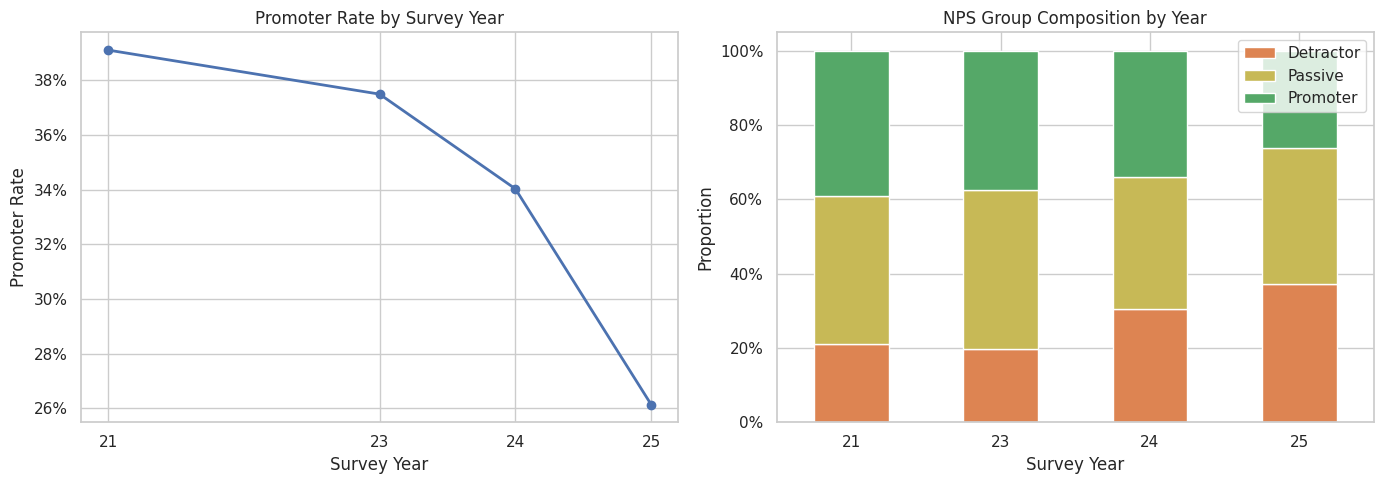

Saved: p1_nps_trend.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Promoter rate by year
promo_by_year = df.groupby('survey_year')['is_promoter'].mean()
promo_by_year.plot(kind='line', marker='o', ax=axes[0], color='#4C72B0', linewidth=2)
axes[0].set_title('Promoter Rate by Survey Year')
axes[0].set_xlabel('Survey Year')
axes[0].set_ylabel('Promoter Rate')
axes[0].yaxis.set_major_formatter(pct_fmt)
axes[0].set_xticks(sorted(df['survey_year'].unique()))

# NPS group breakdown by year (stacked bar)
nps_pct = df.groupby(['survey_year', 'nps_group']).size().unstack(fill_value=0)
nps_pct = nps_pct.div(nps_pct.sum(axis=1), axis=0)
color_map = {'Promoter': '#55A868', 'Passive': '#C7B956', 'Detractor': '#DD8452'}
nps_pct[['Detractor', 'Passive', 'Promoter']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[color_map['Detractor'], color_map['Passive'], color_map['Promoter']],
    edgecolor='white'
)
axes[1].set_title('NPS Group Composition by Year')
axes[1].set_xlabel('Survey Year')
axes[1].set_ylabel('Proportion')
axes[1].yaxis.set_major_formatter(pct_fmt)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('p1_nps_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p1_nps_trend.png')

In [10]:
print('Z-Tests: Each Year vs 2021 Baseline ')
base = df[df['survey_year'] == 21]['is_promoter'] # Changed 2021 to 21
for yr in sorted(df['survey_year'].unique()):
    if yr == 21: # Changed 2021 to 21
        continue
    comp = df[df['survey_year'] == yr]['is_promoter']
    z, p = proportions_ztest([base.sum(), comp.sum()], [len(base), len(comp)])
    sig = '* significant' if p < 0.05 else ''
    print(f'  2021 vs {yr}: z={z:.2f}, p={p:.4f} {sig}')

Z-Tests: Each Year vs 2021 Baseline 
  2021 vs 23: z=0.35, p=0.7243 
  2021 vs 24: z=1.39, p=0.1632 
  2021 vs 25: z=3.57, p=0.0004 * significant


---
## P2: NPS by Primary Media Category

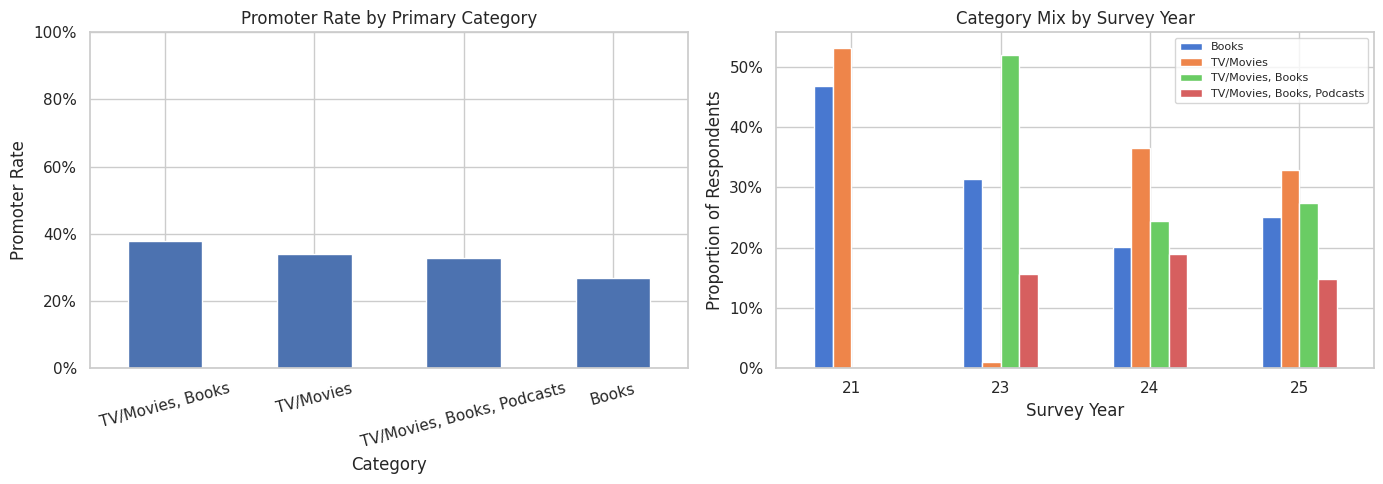

Saved: p2_category.png


In [11]:
categories_to_drop = ['Podcasts', 'Books, Podcasts', 'TV/Movies, Podcasts']
filtered_df = df[~df['primary_category'].isin(categories_to_drop)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Promoter rate by category
cat_promo = filtered_df.groupby('primary_category')['is_promoter'].mean().sort_values(ascending=False)
cat_promo.plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Promoter Rate by Primary Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Promoter Rate')
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(pct_fmt)
axes[0].tick_params(axis='x', rotation=15)

# Category breakdown by year
cat_year = filtered_df.groupby(['survey_year', 'primary_category']).size().unstack(fill_value=0)
cat_year = cat_year.div(cat_year.sum(axis=1), axis=0)
cat_year.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Category Mix by Survey Year')
axes[1].set_xlabel('Survey Year')
axes[1].set_ylabel('Proportion of Respondents')
axes[1].yaxis.set_major_formatter(pct_fmt)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('p2_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p2_category.png')

In [12]:
# Logistic regression: category + year predicts Promoter
categories_to_drop = ['Podcasts', 'Books, Podcasts', 'TV/Movies, Podcasts']
reg_p2 = df_all[~df_all['primary_category'].isin(categories_to_drop)][['is_promoter', 'primary_category', 'survey_year']].dropna().copy()

print(f'Sample: {len(reg_p2)} rows')
print(f'Categories: {sorted(reg_p2["primary_category"].unique())}')

model_p2 = smf.logit(
    'is_promoter ~ C(primary_category, Treatment(reference="TV/Movies")) + survey_year',
    data=reg_p2
).fit()

or_p2 = pd.DataFrame({
    'Odds Ratio':    np.exp(model_p2.params).round(3),
    '95% CI Lower': np.exp(model_p2.conf_int()[0]).round(3),
    '95% CI Upper': np.exp(model_p2.conf_int()[1]).round(3),
    'p-value':       model_p2.pvalues.round(3),
    'Significant':   model_p2.pvalues < 0.05
})
display(or_p2)
print('\nOR > 1 = more likely Promoter vs TV/Movies | p < 0.05 = significant')
print('survey_year coefficient: positive = NPS trending up over time')

Sample: 1417 rows
Categories: ['Books', 'TV/Movies', 'TV/Movies, Books', 'TV/Movies, Books, Podcasts']
Optimization terminated successfully.
         Current function value: 0.623688
         Iterations 5


,Odds Ratio,95% CI Lower,95% CI Upper,p-value,Significant
Intercept,26.361,3.627,191.604,0.001,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books]",0.687,0.511,0.924,0.013,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books]",1.318,0.983,1.768,0.065,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books, Podcasts]",1.077,0.751,1.544,0.686,False
survey_year,0.845,0.777,0.920,0.000,True



OR > 1 = more likely Promoter vs TV/Movies | p < 0.05 = significant
survey_year coefficient: positive = NPS trending up over time


---
## P3: NPS by Total Sessions (Engagement)

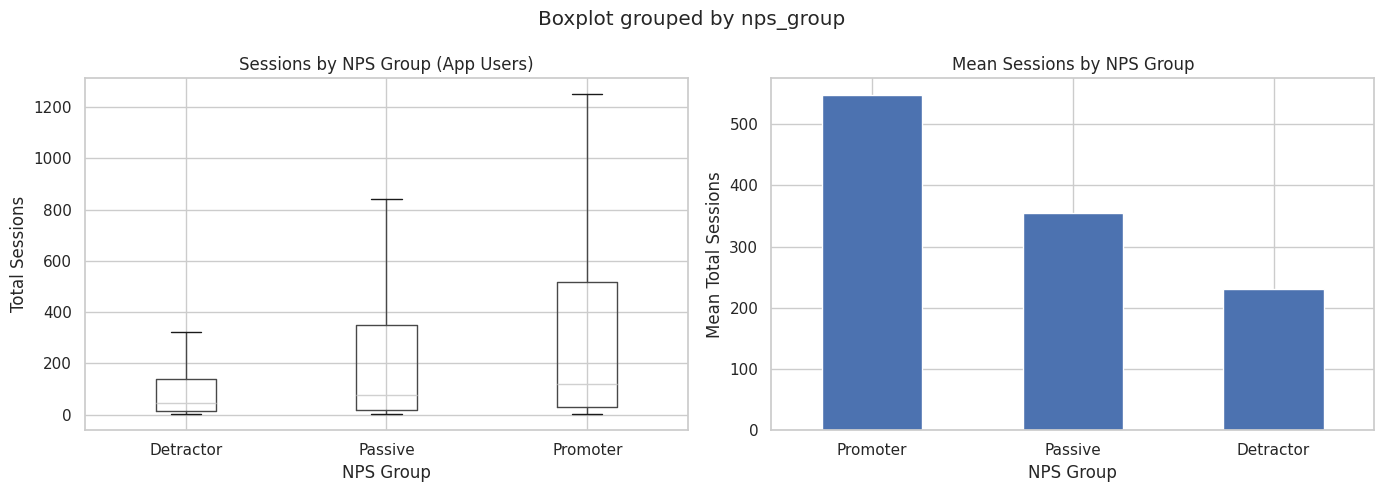

Saved: p3_sessions.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sessions distribution by NPS group
df_app.boxplot(column='total_sessions', by='nps_group',
               ax=axes[0], showfliers=False)
axes[0].set_title('Sessions by NPS Group (App Users)')
axes[0].set_xlabel('NPS Group')
axes[0].set_ylabel('Total Sessions')
plt.sca(axes[0])
plt.title('Sessions by NPS Group (App Users)')

# Mean sessions by NPS group
mean_sess = df_app.groupby('nps_group')['total_sessions'].mean().reindex(
    ['Promoter', 'Passive', 'Detractor'])
mean_sess.plot(kind='bar', ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Mean Sessions by NPS Group')
axes[1].set_xlabel('NPS Group')
axes[1].set_ylabel('Mean Total Sessions')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('p3_sessions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p3_sessions.png')

In [14]:
# Logistic regression: sessions predicts Promoter (ProductA users)
categories_to_drop = ['Podcasts', 'Books, Podcasts', 'TV/Movies, Podcasts']
reg_p3 = df_app[~df_app['primary_category'].isin(categories_to_drop)][['is_promoter', 'log_sessions', 'primary_category', 'survey_year']].dropna().copy()

print(f'Sample: {len(reg_p3)} rows')
model_p3 = smf.logit(
    'is_promoter ~ log_sessions + C(primary_category, Treatment(reference="TV/Movies")) + survey_year',
    data=reg_p3
).fit()

or_p3 = pd.DataFrame({
    'Odds Ratio':    np.exp(model_p3.params).round(3),
    '95% CI Lower': np.exp(model_p3.conf_int()[0]).round(3),
    '95% CI Upper': np.exp(model_p3.conf_int()[1]).round(3),
    'p-value':       model_p3.pvalues.round(3),
    'Significant':   model_p3.pvalues < 0.05
})
display(or_p3)
print('\nlog_sessions OR > 1 = more sessions = more likely to be a Promoter')

Sample: 1027 rows
Optimization terminated successfully.
         Current function value: 0.627174
         Iterations 5


,Odds Ratio,95% CI Lower,95% CI Upper,p-value,Significant
Intercept,1.129,0.100,12.779,0.922,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books]",0.748,0.528,1.059,0.101,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books]",1.631,1.150,2.312,0.006,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books, Podcasts]",1.340,0.840,2.139,0.219,False
log_sessions,1.212,1.120,1.312,0.000,True
survey_year,0.930,0.843,1.026,0.150,False



log_sessions OR > 1 = more sessions = more likely to be a Promoter


---
## P4: ProductA vs ProductB Users — NPS Comparison

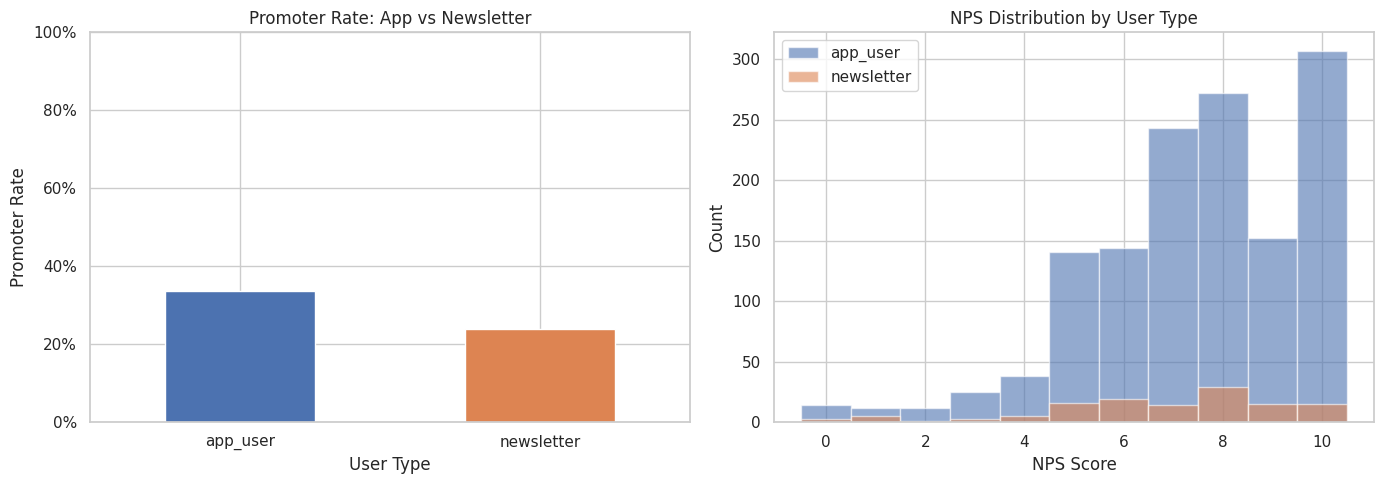

Saved: p4_user_type.png

 Z-Test: App vs Newsletter 
App Promoter rate:        33.8% (n=1360)
Newsletter Promoter rate: 24.0% (n=125)
Z=2.220, p=0.0264
Significant


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Promoter rate by user type
ut_promo = df.groupby('user_type')['is_promoter'].mean()
ut_promo.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Promoter Rate: App vs Newsletter')
axes[0].set_xlabel('User Type')
axes[0].set_ylabel('Promoter Rate')
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(pct_fmt)
axes[0].tick_params(axis='x', rotation=0)

# NPS distribution by user type
for ut, color in [('app_user', '#4C72B0'), ('newsletter', '#DD8452')]:
    subset = df[df['user_type'] == ut]['nps']
    axes[1].hist(subset, bins=11, range=(-0.5, 10.5),
                 alpha=0.6, label=ut, color=color)
axes[1].set_title('NPS Distribution by User Type')
axes[1].set_xlabel('NPS Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('p4_user_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p4_user_type.png')

# Z-test: app users vs newsletter users
app_promo  = df_app['is_promoter']
news_promo = df_news['is_promoter']
z, p = proportions_ztest(
    [app_promo.sum(), news_promo.sum()],
    [len(app_promo), len(news_promo)]
)
print(f'\n Z-Test: App vs Newsletter ')
print(f'App Promoter rate:        {app_promo.mean()*100:.1f}% (n={len(app_promo)})')
print(f'Newsletter Promoter rate: {news_promo.mean()*100:.1f}% (n={len(news_promo)})')
print(f'Z={z:.3f}, p={p:.4f}')
print('Significant' if p < 0.05 else 'Not significant')

---
# SECONDARY ANALYSES
---
## S1: Do Early Retention Signals Predict Total Sessions?

W2 active and M2 active as predictors of long-term engagement (linear regression).

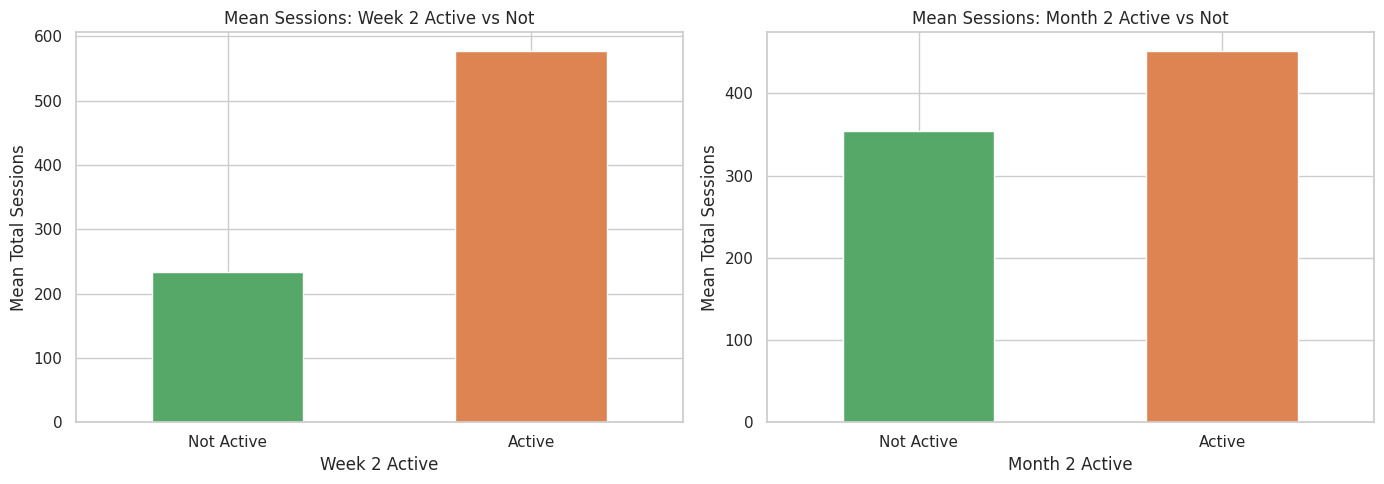

Saved: s1_retention_sessions.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['w2_active', 'm2_active']):
    mean_sess = df_app.groupby(col)['total_sessions'].mean()
    mean_sess.index = mean_sess.index.map({1: 'Active', 0: 'Not Active'})
    mean_sess.plot(kind='bar', ax=axes[i],
                   color=['#55A868', '#DD8452'], edgecolor='white')
    label = 'Week 2' if col == 'w2_active' else 'Month 2'
    axes[i].set_title(f'Mean Sessions: {label} Active vs Not')
    axes[i].set_xlabel(f'{label} Active')
    axes[i].set_ylabel('Mean Total Sessions')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('s1_retention_sessions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s1_retention_sessions.png')

In [17]:
# Linear regression: w2_active + m2_active + genre flags predict log_sessions
reg_s1 = df_app[[
    'log_sessions', 'w2_active', 'm2_active',
    'genres_books', 'genres_screenpla', 'genres_podcasts',
    'log_followers', 'tenure_days'
]].dropna().copy()

print(f'Sample: {len(reg_s1)} rows')
model_s1 = smf.ols(
    'log_sessions ~ w2_active + m2_active + genres_books + genres_screenpla + genres_podcasts + log_followers + tenure_days',
    data=reg_s1
).fit()

print(model_s1.summary())
print(f'\nR-squared: {model_s1.rsquared:.3f}')
print('R-squared = proportion of variance in sessions explained by these predictors')
print('Positive coefficient = this factor is associated with more sessions')

Sample: 646 rows
                            OLS Regression Results                            
Dep. Variable:           log_sessions   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     66.80
Date:                Fri, 29 May 2026   Prob (F-statistic):           4.41e-72
Time:                        21:59:10   Log-Likelihood:                -1087.1
No. Observations:                 646   AIC:                             2190.
Df Residuals:                     638   BIC:                             2226.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.

---
## S2: Do Early Retention Signals Predict NPS?

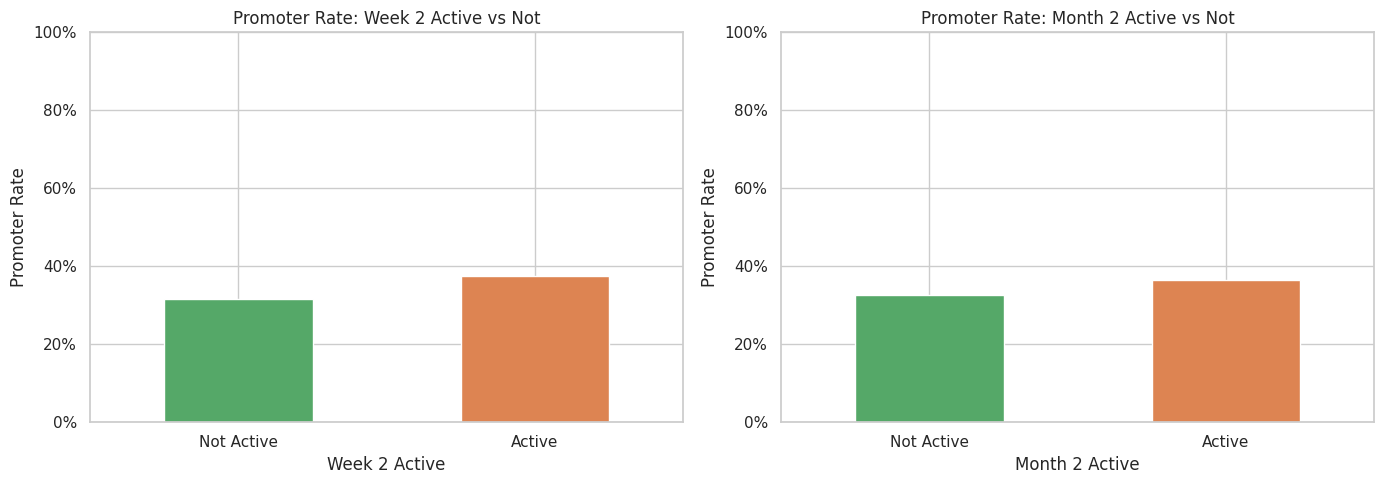

Saved: s2_retention_nps.png
Week 2: Active 37.5% vs Not Active 31.6% — z=2.22, p=0.0267 * significant
Month 2: Active 36.6% vs Not Active 32.5% — z=1.45, p=0.1476 


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['w2_active', 'm2_active']):
    promo_rate = df_app.groupby(col)['is_promoter'].mean()
    promo_rate.index = promo_rate.index.map({1: 'Active', 0: 'Not Active'})
    promo_rate.plot(kind='bar', ax=axes[i],
                    color=['#55A868', '#DD8452'], edgecolor='white')
    label = 'Week 2' if col == 'w2_active' else 'Month 2'
    axes[i].set_title(f'Promoter Rate: {label} Active vs Not')
    axes[i].set_xlabel(f'{label} Active')
    axes[i].set_ylabel('Promoter Rate')
    axes[i].set_ylim(0, 1)
    axes[i].yaxis.set_major_formatter(pct_fmt)
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('s2_retention_nps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s2_retention_nps.png')

# Z-tests: w2 and m2
for col, label in [('w2_active', 'Week 2'), ('m2_active', 'Month 2')]:
    active     = df_app[df_app[col] == 1]['is_promoter']
    not_active = df_app[df_app[col] == 0]['is_promoter']
    if len(active) > 0 and len(not_active) > 0:
        z, p = proportions_ztest(
            [active.sum(), not_active.sum()],
            [len(active), len(not_active)]
        )
        sig = '* significant' if p < 0.05 else ''
        print(f'{label}: Active {active.mean()*100:.1f}% vs Not Active {not_active.mean()*100:.1f}% — z={z:.2f}, p={p:.4f} {sig}')

In [19]:
# Logistic regression: retention signals predict Promoter
categories_to_drop = ['Podcasts', 'Books, Podcasts', 'TV/Movies, Podcasts']
reg_s2 = df_app[~df_app['primary_category'].isin(categories_to_drop)][[
    'is_promoter', 'w2_active', 'm2_active',
    'log_sessions', 'primary_category', 'survey_year'
]].dropna().copy()

print(f'Sample: {len(reg_s2)} rows')
model_s2 = smf.logit(
    'is_promoter ~ w2_active + m2_active + log_sessions + C(primary_category, Treatment(reference="TV/Movies")) + survey_year',
    data=reg_s2
).fit()

or_s2 = pd.DataFrame({
    'Odds Ratio':    np.exp(model_s2.params).round(3),
    '95% CI Lower': np.exp(model_s2.conf_int()[0]).round(3),
    '95% CI Upper': np.exp(model_s2.conf_int()[1]).round(3),
    'p-value':       model_s2.pvalues.round(3),
    'Significant':   model_s2.pvalues < 0.05
})
display(or_s2)

Sample: 1027 rows
Optimization terminated successfully.
         Current function value: 0.627035
         Iterations 5


,Odds Ratio,95% CI Lower,95% CI Upper,p-value,Significant
Intercept,1.215,0.103,14.368,0.877,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books]",0.759,0.534,1.080,0.126,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books]",1.649,1.161,2.344,0.005,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books, Podcasts]",1.350,0.845,2.157,0.209,False
w2_active,0.978,0.707,1.354,0.895,False
m2_active,0.938,0.688,1.280,0.687,False
log_sessions,1.218,1.121,1.324,0.000,True
survey_year,0.927,0.839,1.025,0.141,False


---
## S3: Do Genre Interests Predict Sessions or NPS?

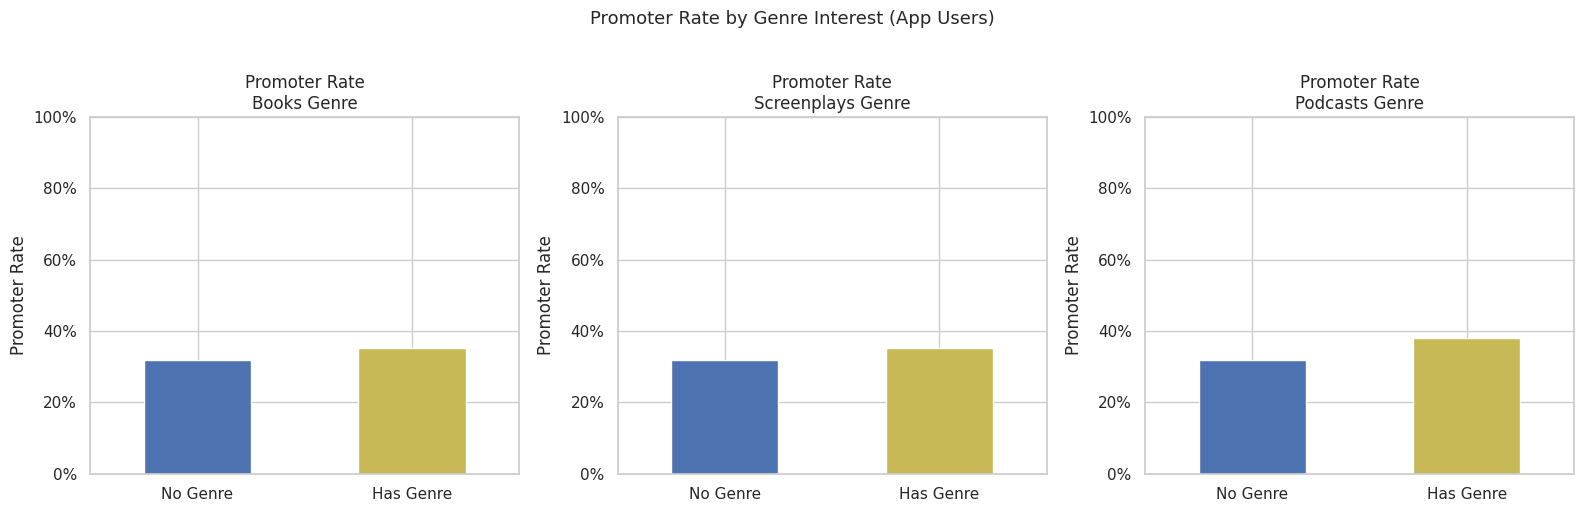

Saved: s3_genres.png

=== Genre Z-Tests: Promoter Rate ===
Books: Has genre 35.2% vs No genre 32.0% — z=1.22, p=0.2240 
Screenplays: Has genre 35.2% vs No genre 32.0% — z=1.26, p=0.2092 
Podcasts: Has genre 38.0% vs No genre 32.0% — z=2.13, p=0.0329 * significant


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
genres = [
    ('genres_books',      'Books'),
    ('genres_screenpla',  'Screenplays'),
    ('genres_podcasts',   'Podcasts')
]

for i, (col, label) in enumerate(genres):
    promo = df_app.groupby(col)['is_promoter'].mean()
    promo.index = promo.index.map({1: 'Has Genre', 0: 'No Genre'})
    promo.plot(kind='bar', ax=axes[i],
               color=['#4C72B0', '#C7B956'], edgecolor='white')
    axes[i].set_title(f'Promoter Rate\n{label} Genre')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Promoter Rate')
    axes[i].set_ylim(0, 1)
    axes[i].yaxis.set_major_formatter(pct_fmt)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Promoter Rate by Genre Interest (App Users)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('s3_genres.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s3_genres.png')

# Z-tests per genre
print('\n=== Genre Z-Tests: Promoter Rate ===')
for col, label in genres:
    has    = df_app[df_app[col] == 1]['is_promoter']
    hasnt  = df_app[df_app[col] == 0]['is_promoter']
    if len(has) > 0 and len(hasnt) > 0:
        z, p = proportions_ztest(
            [has.sum(), hasnt.sum()],
            [len(has), len(hasnt)]
        )
        sig = '* significant' if p < 0.05 else ''
        print(f'{label}: Has genre {has.mean()*100:.1f}% vs No genre {hasnt.mean()*100:.1f}% — z={z:.2f}, p={p:.4f} {sig}')

---
## S4: Demographic Exploration — Age & Gender vs NPS

Age missing: 9 (0.6%)
Gender missing: 0 (0.0%)

Gender values:
gender
Female                  1109
Male                     327
Non-binary                15
Prefer not to say         13
Prefer not to answer      11
Other                      8
nan                        2
Name: count, dtype: int64


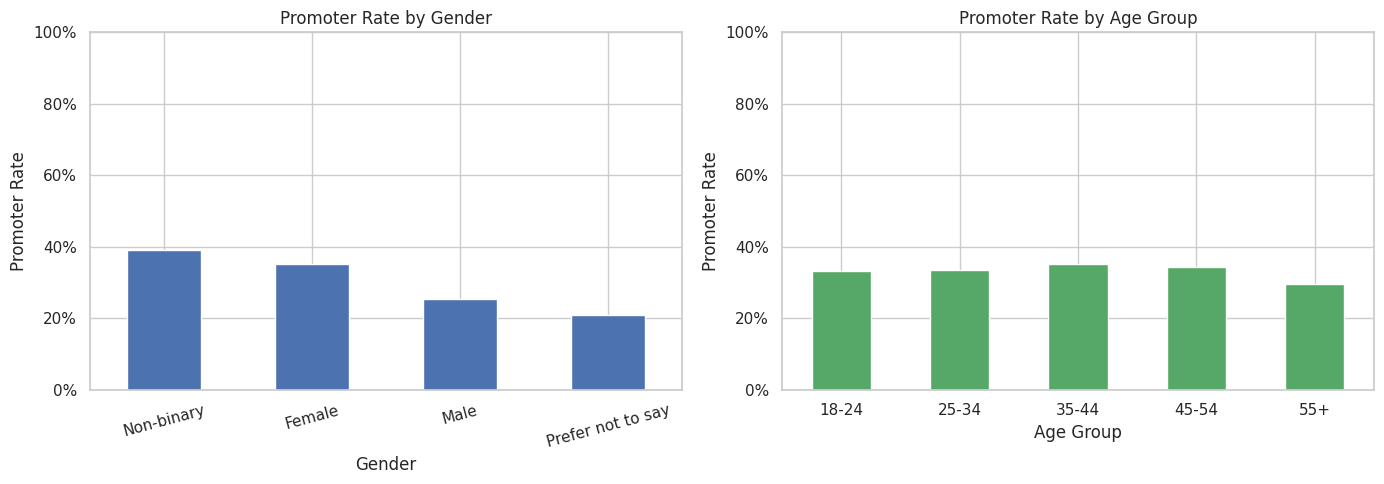

Saved: s4_demographics.png


In [21]:
print(f'Age missing: {df["age"].isna().sum()} ({df["age"].isna().mean()*100:.1f}%)')
print(f'Gender missing: {df["gender"].isna().sum()} ({df["gender"].isna().mean()*100:.1f}%)')
print(f'\nGender values:')
print(df['gender'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create a temporary DataFrame for gender plotting to avoid altering the main df
df_temp_gender = df[df['gender'] != 'nan'].copy() # Filter out 'nan' values from gender

# Consolidate gender categories
df_temp_gender['gender_cleaned'] = df_temp_gender['gender'].replace({
    'Prefer not to answer': 'Prefer not to say',
    'Other': 'Non-binary'
})

# NPS by gender
gender_promo = df_temp_gender.groupby('gender_cleaned')['is_promoter'].mean().sort_values(ascending=False)
gender_promo.plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Promoter Rate by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Promoter Rate')
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(pct_fmt)
axes[0].tick_params(axis='x', rotation=15)

# NPS by age (binned)
df['age_group'] = pd.cut(df['age'],
    bins=[0, 24, 34, 44, 54, 100],
    labels=['18-24', '25-34', '35-44', '45-54', '55+'])
age_promo = df.groupby('age_group')['is_promoter'].mean()
age_promo.plot(kind='bar', ax=axes[1], color='#55A868', edgecolor='white')
axes[1].set_title('Promoter Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Promoter Rate')
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(pct_fmt)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('s4_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s4_demographics.png')

---
## S5: Follower Count vs Sessions & NPS

Does social following predict engagement or satisfaction?

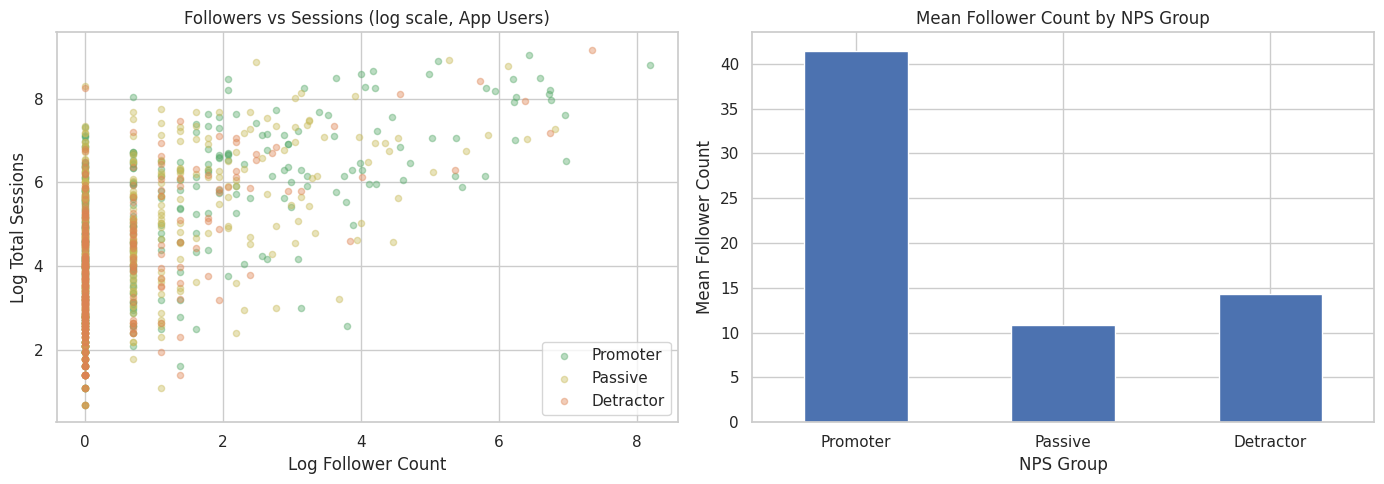

Saved: s5_followers.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Followers vs sessions scatter
plot_df = df_app[['log_followers', 'log_sessions', 'nps_group']].dropna()
for group, color in [('Promoter', '#55A868'), ('Passive', '#C7B956'), ('Detractor', '#DD8452')]:
    sub = plot_df[plot_df['nps_group'] == group]
    axes[0].scatter(sub['log_followers'], sub['log_sessions'],
                    alpha=0.4, label=group, color=color, s=20)
axes[0].set_title('Followers vs Sessions (log scale, App Users)')
axes[0].set_xlabel('Log Follower Count')
axes[0].set_ylabel('Log Total Sessions')
axes[0].legend()

# Mean followers by NPS group
mean_follow = df_app.groupby('nps_group')['follower_count'].mean().reindex(
    ['Promoter', 'Passive', 'Detractor'])
mean_follow.plot(kind='bar', ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Mean Follower Count by NPS Group')
axes[1].set_xlabel('NPS Group')
axes[1].set_ylabel('Mean Follower Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('s5_followers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s5_followers.png')

---
## S6: Full Predictive Model — Everything Together

In [23]:
categories_to_drop = ['Podcasts', 'Books, Podcasts', 'TV/Movies, Podcasts']
reg_s6 = df_app[~df_app['primary_category'].isin(categories_to_drop)][[
    'is_promoter', 'primary_category', 'survey_year',
    'log_sessions', 'w2_active', 'm2_active',
    'genres_books', 'genres_screenpla', 'genres_podcasts',
    'log_followers', 'tenure_days'
]].dropna().copy()

print(f'Full model sample: {len(reg_s6)} rows')
if len(reg_s6) < 100:
    print('Warning: sample under 100 — interpret results cautiously.')

model_s6 = smf.logit(
    'is_promoter ~ C(primary_category, Treatment(reference="TV/Movies")) + survey_year + '
    'log_sessions + w2_active + m2_active + '
    'genres_books + genres_screenpla + genres_podcasts + '
    'log_followers + tenure_days',
    data=reg_s6
).fit()

or_s6 = pd.DataFrame({
    'Odds Ratio':    np.exp(model_s6.params).round(3),
    '95% CI Lower': np.exp(model_s6.conf_int()[0]).round(3),
    '95% CI Upper': np.exp(model_s6.conf_int()[1]).round(3),
    'p-value':       model_s6.pvalues.round(3),
    'Significant':   model_s6.pvalues < 0.05
})
display(or_s6)

sig_s6 = or_s6[(or_s6['Significant']) & (or_s6.index != 'Intercept')]
print()
if len(sig_s6) > 0:
    print('Significant predictors after controlling for all others:')
    for name, row in sig_s6.iterrows():
        direction = 'more' if row['Odds Ratio'] > 1 else 'less'
        print(f'  * {name}: OR={row["Odds Ratio"]:.2f} ({direction} likely to be a Promoter)')
else:
    print('No significant predictors in full model — may reflect small sample or multicollinearity.')

Full model sample: 620 rows
Optimization terminated successfully.
         Current function value: 0.611269
         Iterations 5


,Odds Ratio,95% CI Lower,95% CI Upper,p-value,Significant
Intercept,0.986,0.019,52.218,0.994,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books]",0.895,0.527,1.522,0.683,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books]",2.348,1.448,3.807,0.001,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books, Podcasts]",1.870,1.013,3.453,0.045,True
survey_year,0.920,0.794,1.065,0.262,False
log_sessions,1.183,1.032,1.356,0.016,True
w2_active,0.752,0.487,1.163,0.200,False
m2_active,1.205,0.775,1.874,0.407,False
genres_books,1.244,0.763,2.030,0.381,False
genres_screenpla,1.084,0.668,1.760,0.743,False



Significant predictors after controlling for all others:
  * C(primary_category, Treatment(reference="TV/Movies"))[T.TV/Movies, Books]: OR=2.35 (more likely to be a Promoter)
  * C(primary_category, Treatment(reference="TV/Movies"))[T.TV/Movies, Books, Podcasts]: OR=1.87 (more likely to be a Promoter)
  * log_sessions: OR=1.18 (more likely to be a Promoter)
  * log_followers: OR=1.18 (more likely to be a Promoter)


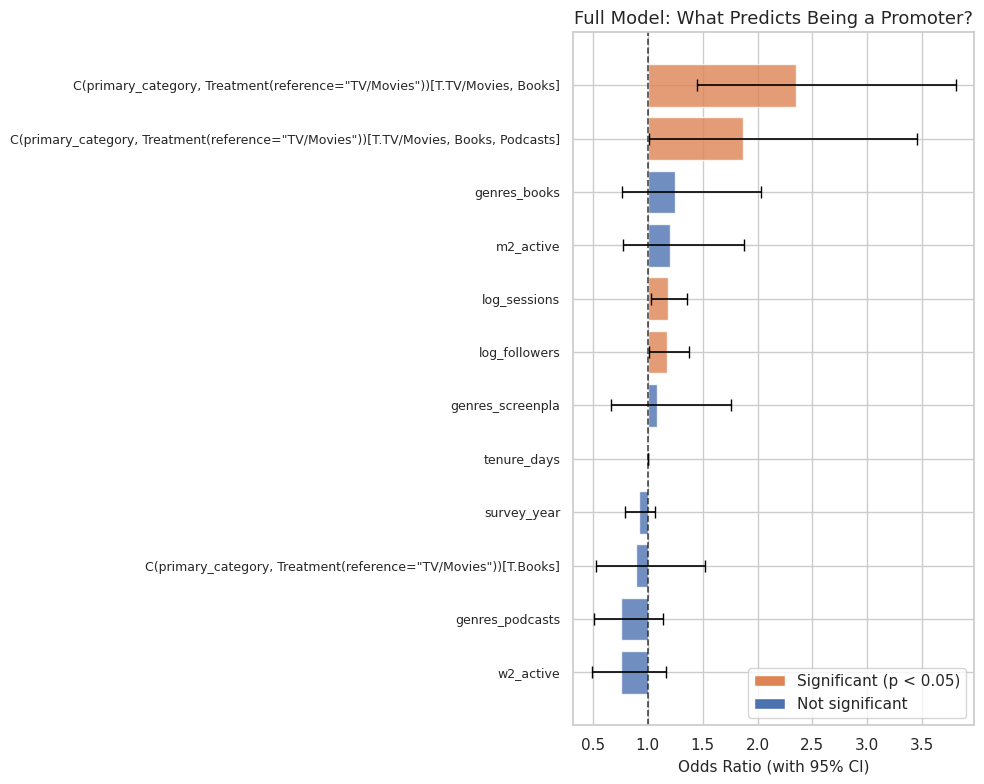

Saved: s6_full_model.png


In [24]:
# Forest plot — full model
plot_df = or_s6[or_s6.index != 'Intercept'].copy().sort_values('Odds Ratio')
colors  = ['#DD8452' if s else '#4C72B0' for s in plot_df['Significant']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(plot_df)), plot_df['Odds Ratio'] - 1, left=1,
        color=colors, alpha=0.8, edgecolor='white')
ax.errorbar(
    plot_df['Odds Ratio'], range(len(plot_df)),
    xerr=[plot_df['Odds Ratio'] - plot_df['95% CI Lower'],
          plot_df['95% CI Upper'] - plot_df['Odds Ratio']],
    fmt='none', color='black', capsize=4, linewidth=1.2
)
ax.axvline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=9)
ax.set_xlabel('Odds Ratio (with 95% CI)', fontsize=11)
ax.set_title('Full Model: What Predicts Being a Promoter?', fontsize=13)
ax.legend(handles=[
    Patch(facecolor='#DD8452', label='Significant (p < 0.05)'),
    Patch(facecolor='#4C72B0', label='Not significant')
], loc='lower right')

plt.tight_layout()
plt.savefig('s6_full_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s6_full_model.png')

---
## Summary & Limitations

---

## New Analysis: Primary vs. Behavioral Categories for NPS

In [25]:
def create_behavioral_category(row):
    categories = []
    if row['genres_screenpla'] == 1:
        categories.append('TV/Movies')
    if row['genres_books'] == 1:
        categories.append('Books')
    if row['genres_podcasts'] == 1:
        categories.append('Podcasts')

    if not categories:
        return 'No Behavioral Category' # Assign if no specific genre is active
    return ', '.join(sorted(categories)) # Sort to ensure consistent string representation

# Helper function to fit logistic regression and generate forest plot
def fit_and_plot_model(
    df_data, category_col, ref_category, plot_title, filename
):
    reg_df = df_data[[
        'is_promoter', category_col
    ]].dropna().copy()

    print(f'\n--- {plot_title} ---')
    print(f'Sample for {plot_title}: {len(reg_df)} rows')

    # Construct the formula dynamically
    formula = (
        f'is_promoter ~ C({category_col}, Treatment(reference="{ref_category}"))'
    )

    model = smf.logit(formula, data=reg_df).fit(disp=False) # disp=False to suppress iteration output

    or_results = pd.DataFrame({
        'Odds Ratio':    np.exp(model.params).round(3),
        '95% CI Lower': np.exp(model.conf_int()[0]).round(3),
        '95% CI Upper': np.exp(model.conf_int()[1]).round(3),
        'p-value':       model.pvalues.round(3),
        'Significant':   model.pvalues < 0.05
    })
    display(or_results)

    sig_results = or_results[(or_results['Significant']) & (or_results.index != 'Intercept')]
    print()
    if len(sig_results) > 0:
        print(f'Significant predictors in {plot_title} model:')
        for name, row in sig_results.iterrows():
            direction = 'more' if row['Odds Ratio'] > 1 else 'less'
            print(f'  * {name}: OR={row["Odds Ratio"]:.2f} ({direction} likely to be a Promoter)')
    else:
        print(f'No significant predictors in {plot_title} model.')

    # Forest plot
    plot_df = or_results[or_results.index != 'Intercept'].copy().sort_values('Odds Ratio')
    colors  = ['#DD8452' if s else '#4C72B0' for s in plot_df['Significant']]

    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.5))) # Adjust figure size dynamically
    ax.barh(range(len(plot_df)), plot_df['Odds Ratio'] - 1, left=1,
            color=colors, alpha=0.8, edgecolor='white')
    ax.errorbar(
        plot_df['Odds Ratio'], range(len(plot_df)),
        xerr=[plot_df['Odds Ratio'] - plot_df['95% CI Lower'],
              plot_df['95% CI Upper'] - plot_df['Odds Ratio']],
        fmt='none', color='black', capsize=4, linewidth=1.2
    )
    ax.axvline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df.index, fontsize=9)
    ax.set_xlabel('Odds Ratio (with 95% CI)', fontsize=11)
    ax.set_title(plot_title, fontsize=13)
    ax.legend(handles=[
        Patch(facecolor='#DD8452', label='Significant (p < 0.05)'),
        Patch(facecolor='#4C72B0', label='Not significant')
    ], loc='lower right')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

In [26]:
df_app['behavioral_category'] = df_app.apply(create_behavioral_category, axis=1)

print("Behavioral Category Value Counts (App Users):")
print(df_app['behavioral_category'].value_counts())

Behavioral Category Value Counts (App Users):
behavioral_category
No Behavioral Category        402
Books, Podcasts, TV/Movies    306
Books, TV/Movies              266
TV/Movies                     145
Books                         144
Podcasts                       38
Books, Podcasts                32
Podcasts, TV/Movies            27
Name: count, dtype: int64


Model A: Primary (Self-Reported) Category Predicting Promoter Status


--- Model A: Primary Category vs. Promoter Status ---
Sample for Model A: Primary Category vs. Promoter Status: 1360 rows


,Odds Ratio,95% CI Lower,95% CI Upper,p-value,Significant
Intercept,0.516,0.423,0.630,0.000,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books]",0.725,0.534,0.985,0.040,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts]",0.714,0.293,1.738,0.458,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Podcasts]",1.108,0.319,3.845,0.872,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books]",1.295,0.963,1.743,0.087,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books, Podcasts]",1.027,0.712,1.483,0.886,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Podcasts]",1.246,0.527,2.947,0.616,False



Significant predictors in Model A: Primary Category vs. Promoter Status model:
  * C(primary_category, Treatment(reference="TV/Movies"))[T.Books]: OR=0.72 (less likely to be a Promoter)


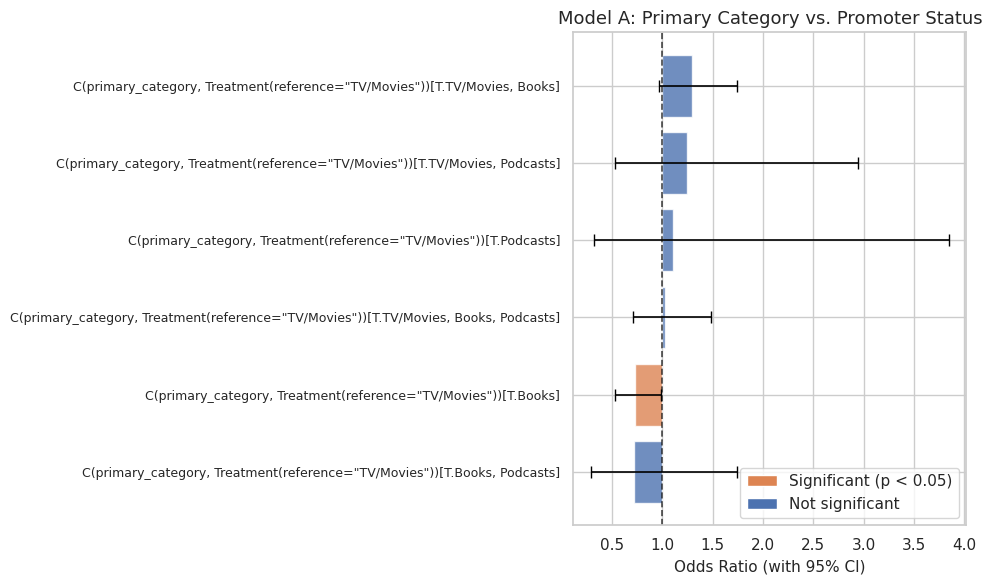

Saved: model_A_primary_category_forest_plot.png


In [27]:
fit_and_plot_model(
    df_app,
    category_col='primary_category',
    ref_category='TV/Movies',
    plot_title='Model A: Primary Category vs. Promoter Status',
    filename='model_A_primary_category_forest_plot.png'
)

### Model B: Behavioral Category Predicting Promoter Status


--- Model B: Behavioral Category vs. Promoter Status ---
Sample for Model B: Behavioral Category vs. Promoter Status: 1360 rows


,Odds Ratio,95% CI Lower,95% CI Upper,p-value,Significant
Intercept,0.422,0.295,0.602,0.000,True
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books]",0.881,0.528,1.470,0.628,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts]",1.623,0.736,3.577,0.230,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts, TV/Movies]",1.489,0.974,2.276,0.066,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books, TV/Movies]",1.275,0.824,1.973,0.275,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.No Behavioral Category]",1.147,0.759,1.733,0.516,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Podcasts]",1.384,0.654,2.927,0.396,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Podcasts, TV/Movies]",0.999,0.406,2.456,0.998,False



No significant predictors in Model B: Behavioral Category vs. Promoter Status model.


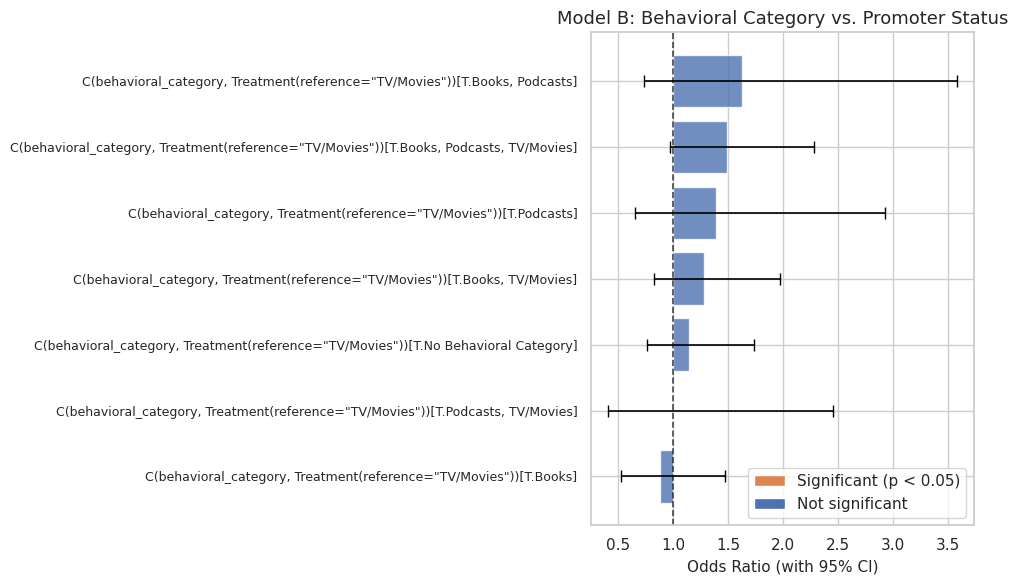

Saved: model_B_behavioral_category_forest_plot.png


In [28]:
fit_and_plot_model(
    df_app,
    category_col='behavioral_category',
    ref_category='TV/Movies',
    plot_title='Model B: Behavioral Category vs. Promoter Status',
    filename='model_B_behavioral_category_forest_plot.png'
)

### Combined Model: Primary and Behavioral Categories Predicting Promoter Status

This model includes both the `primary_category` and the `behavioral_category` to see their joint effect on Promoter status. We'll examine if either or both remain significant when controlling for the other.


--- Combined Model: Primary + Behavioral Categories ---
Sample for Combined Model: 1360 rows


,Odds Ratio,95% CI Lower,95% CI Upper,p-value,Significant
Intercept,0.414,0.285,0.601,0.000,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books]",0.689,0.496,0.959,0.027,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts]",0.616,0.250,1.518,0.292,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Podcasts]",0.982,0.279,3.460,0.978,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books]",1.214,0.890,1.655,0.221,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books, Podcasts]",1.016,0.702,1.470,0.933,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Podcasts]",1.237,0.521,2.935,0.630,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books]",1.102,0.640,1.897,0.726,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts]",1.828,0.812,4.118,0.145,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts, TV/Movies]",1.614,1.042,2.498,0.032,True



Significant predictors in Combined Model:
  * C(primary_category, Treatment(reference="TV/Movies"))[T.Books]: OR=0.69 (less likely to be a Promoter)
  * C(behavioral_category, Treatment(reference="TV/Movies"))[T.Books, Podcasts, TV/Movies]: OR=1.61 (more likely to be a Promoter)


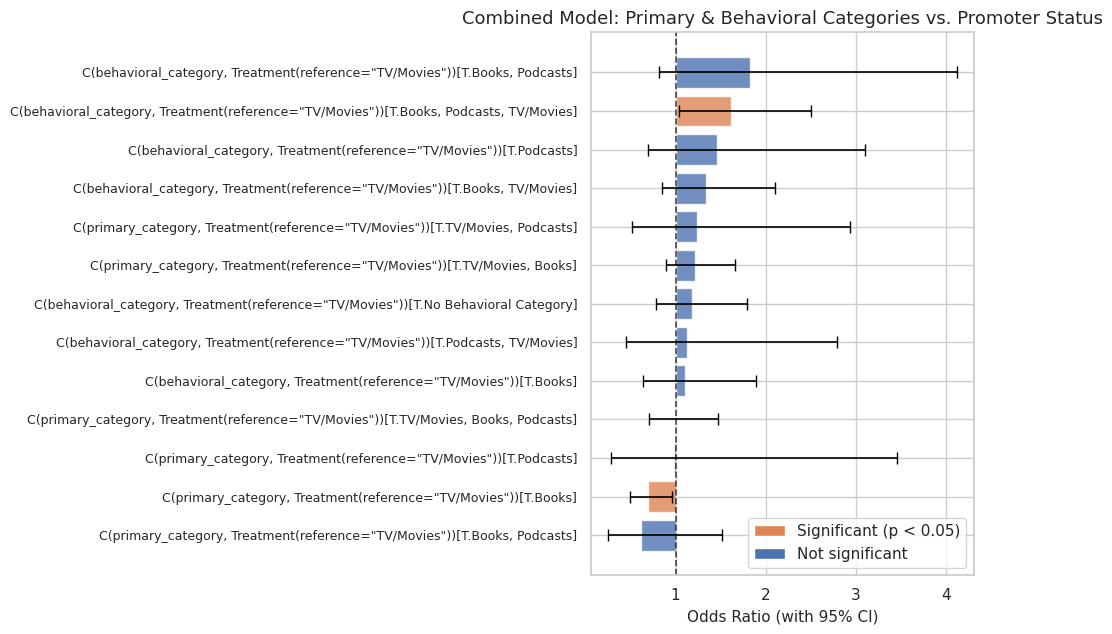

Saved: combined_primary_behavioral_forest_plot.png


In [29]:
combined_reg_df = df_app[[
    'is_promoter', 'primary_category', 'behavioral_category'
]].dropna().copy()

print(f'\n--- Combined Model: Primary + Behavioral Categories ---')
print(f'Sample for Combined Model: {len(combined_reg_df)} rows')

# Construct the formula dynamically with both categorical variables
# We need to explicitly handle reference categories for both
formula_combined = (
    'is_promoter ~ C(primary_category, Treatment(reference="TV/Movies")) + '
    'C(behavioral_category, Treatment(reference="TV/Movies"))'
)

combined_model = smf.logit(formula_combined, data=combined_reg_df).fit(disp=False)

combined_or_results = pd.DataFrame({
    'Odds Ratio':    np.exp(combined_model.params).round(3),
    '95% CI Lower': np.exp(combined_model.conf_int()[0]).round(3),
    '95% CI Upper': np.exp(combined_model.conf_int()[1]).round(3),
    'p-value':       combined_model.pvalues.round(3),
    'Significant':   combined_model.pvalues < 0.05
})
display(combined_or_results)

sig_combined_results = combined_or_results[(
    combined_or_results['Significant']) & (combined_or_results.index != 'Intercept')
]
print()
if len(sig_combined_results) > 0:
    print(f'Significant predictors in Combined Model:')
    for name, row in sig_combined_results.iterrows():
        direction = 'more' if row['Odds Ratio'] > 1 else 'less'
        print(f'  * {name}: OR={row["Odds Ratio"]:.2f} ({direction} likely to be a Promoter)')
else:
    print(f'No significant predictors in Combined Model.')

# Forest plot for combined model
plot_df_combined = combined_or_results[combined_or_results.index != 'Intercept'].copy().sort_values('Odds Ratio')
colors_combined  = ['#DD8452' if s else '#4C72B0' for s in plot_df_combined['Significant']]

fig_combined, ax_combined = plt.subplots(figsize=(10, max(6, len(plot_df_combined) * 0.5)))
ax_combined.barh(range(len(plot_df_combined)), plot_df_combined['Odds Ratio'] - 1, left=1,
        color=colors_combined, alpha=0.8, edgecolor='white')
ax_combined.errorbar(
    plot_df_combined['Odds Ratio'], range(len(plot_df_combined)),
    xerr=[plot_df_combined['Odds Ratio'] - plot_df_combined['95% CI Lower'],
          plot_df_combined['95% CI Upper'] - plot_df_combined['Odds Ratio']],
    fmt='none', color='black', capsize=4, linewidth=1.2
)
ax_combined.axvline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax_combined.set_yticks(range(len(plot_df_combined)))
ax_combined.set_yticklabels(plot_df_combined.index, fontsize=9)
ax_combined.set_xlabel('Odds Ratio (with 95% CI)', fontsize=11)
ax_combined.set_title('Combined Model: Primary & Behavioral Categories vs. Promoter Status', fontsize=13)
ax_combined.legend(handles=[
    Patch(facecolor='#DD8452', label='Significant (p < 0.05)'),
    Patch(facecolor='#4C72B0', label='Not significant')
], loc='lower right')

plt.tight_layout()
plt.savefig('combined_primary_behavioral_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: combined_primary_behavioral_forest_plot.png')


### Combined Model with `log_sessions`: Primary & Behavioral Categories Predicting Promoter Status

This model adds `log_sessions` to the combined model, allowing us to see the independent effects of `primary_category`, `behavioral_category`, and `log_sessions` on Promoter status.


--- Combined Model: Primary + Behavioral Categories + log_sessions ---
Sample for Combined Model with Sessions: 1070 rows


,Odds Ratio,95% CI Lower,95% CI Upper,p-value,Significant
Intercept,0.187,0.104,0.338,0.000,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books]",0.769,0.532,1.111,0.161,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts]",1.085,0.420,2.805,0.866,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Podcasts]",1.165,0.248,5.478,0.847,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books]",1.539,1.076,2.202,0.018,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books, Podcasts]",1.285,0.804,2.056,0.295,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Podcasts]",1.352,0.424,4.308,0.610,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books]",0.985,0.521,1.861,0.963,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts]",1.224,0.510,2.938,0.652,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts, TV/Movies]",1.099,0.643,1.879,0.729,False



Significant predictors in Combined Model with Sessions:
  * C(primary_category, Treatment(reference="TV/Movies"))[T.TV/Movies, Books]: OR=1.54 (more likely to be a Promoter)
  * log_sessions: OR=1.23 (more likely to be a Promoter)


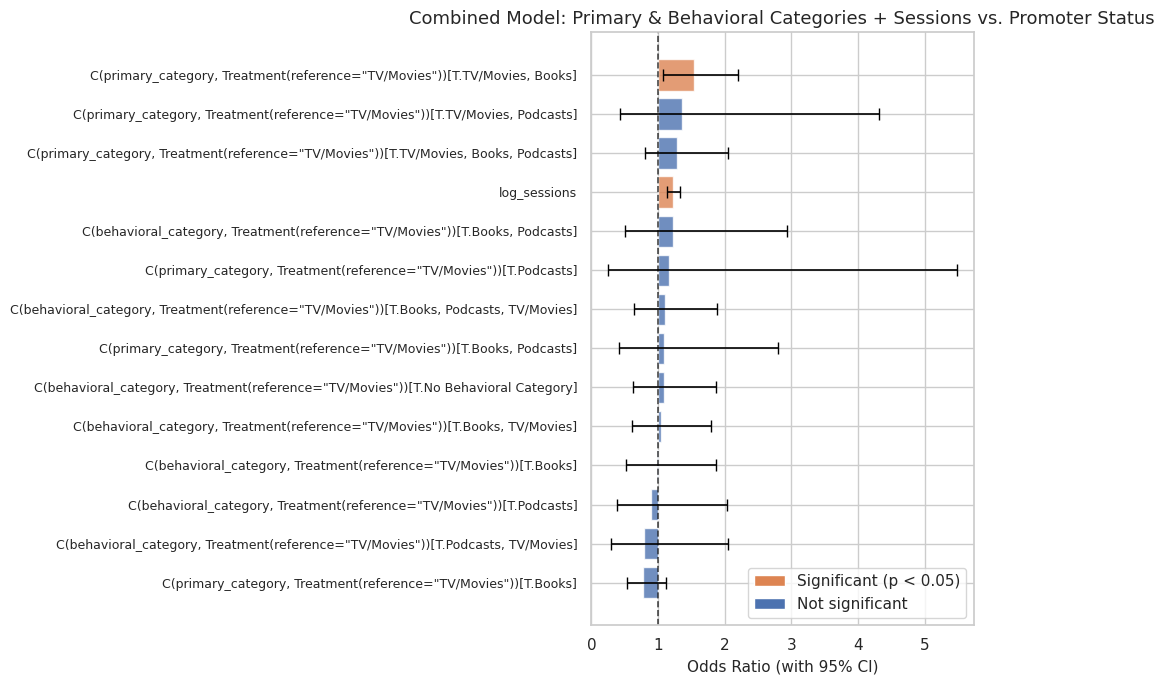

Saved: combined_primary_behavioral_sessions_forest_plot.png


In [30]:
combined_reg_df_sessions = df_app[[
    'is_promoter', 'primary_category', 'behavioral_category', 'log_sessions'
]].dropna().copy()

print(f'\n--- Combined Model: Primary + Behavioral Categories + log_sessions ---')
print(f'Sample for Combined Model with Sessions: {len(combined_reg_df_sessions)} rows')

formula_combined_sessions = (
    'is_promoter ~ C(primary_category, Treatment(reference="TV/Movies")) + '
    'C(behavioral_category, Treatment(reference="TV/Movies")) + '
    'log_sessions'
)

combined_model_sessions = smf.logit(formula_combined_sessions, data=combined_reg_df_sessions).fit(disp=False)

combined_or_results_sessions = pd.DataFrame({
    'Odds Ratio':    np.exp(combined_model_sessions.params).round(3),
    '95% CI Lower': np.exp(combined_model_sessions.conf_int()[0]).round(3),
    '95% CI Upper': np.exp(combined_model_sessions.conf_int()[1]).round(3),
    'p-value':       combined_model_sessions.pvalues.round(3),
    'Significant':   combined_model_sessions.pvalues < 0.05
})
display(combined_or_results_sessions)

sig_combined_results_sessions = combined_or_results_sessions[(
    combined_or_results_sessions['Significant']) & (combined_or_results_sessions.index != 'Intercept')
]
print()
if len(sig_combined_results_sessions) > 0:
    print(f'Significant predictors in Combined Model with Sessions:')
    for name, row in sig_combined_results_sessions.iterrows():
        direction = 'more' if row['Odds Ratio'] > 1 else 'less'
        print(f'  * {name}: OR={row["Odds Ratio"]:.2f} ({direction} likely to be a Promoter)')
else:
    print(f'No significant predictors in Combined Model with Sessions.')

# Forest plot for combined model with sessions
plot_df_combined_sessions = combined_or_results_sessions[combined_or_results_sessions.index != 'Intercept'].copy().sort_values('Odds Ratio')
colors_combined_sessions  = ['#DD8452' if s else '#4C72B0' for s in plot_df_combined_sessions['Significant']]

fig_combined_sessions, ax_combined_sessions = plt.subplots(figsize=(10, max(6, len(plot_df_combined_sessions) * 0.5)))
ax_combined_sessions.barh(range(len(plot_df_combined_sessions)), plot_df_combined_sessions['Odds Ratio'] - 1, left=1,
        color=colors_combined_sessions, alpha=0.8, edgecolor='white')
ax_combined_sessions.errorbar(
    plot_df_combined_sessions['Odds Ratio'], range(len(plot_df_combined_sessions)),
    xerr=[plot_df_combined_sessions['Odds Ratio'] - plot_df_combined_sessions['95% CI Lower'],
          plot_df_combined_sessions['95% CI Upper'] - plot_df_combined_sessions['Odds Ratio']],
    fmt='none', color='black', capsize=4, linewidth=1.2
)
ax_combined_sessions.axvline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax_combined_sessions.set_yticks(range(len(plot_df_combined_sessions)))
ax_combined_sessions.set_yticklabels(plot_df_combined_sessions.index, fontsize=9)
ax_combined_sessions.set_xlabel('Odds Ratio (with 95% CI)', fontsize=11)
ax_combined_sessions.set_title('Combined Model: Primary & Behavioral Categories + Sessions vs. Promoter Status', fontsize=13)
ax_combined_sessions.legend(handles=[
    Patch(facecolor='#DD8452', label='Significant (p < 0.05)'),
    Patch(facecolor='#4C72B0', label='Not significant')
], loc='lower right')

plt.tight_layout()
plt.savefig('combined_primary_behavioral_sessions_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: combined_primary_behavioral_sessions_forest_plot.png')

### Participant Counts for Combined Model with Sessions Cohorts

In [31]:
print('Participant counts by Primary Category and Behavioral Category (Combined Model with Sessions):')
display(combined_reg_df_sessions.groupby(['primary_category', 'behavioral_category']).size().reset_index(name='count').sort_values(by='count', ascending=False))

Participant counts by Primary Category and Behavioral Category (Combined Model with Sessions):


,primary_category,behavioral_category,count
30,"TV/Movies, Books","Books, TV/Movies",107
23,TV/Movies,No Behavioral Category,91
2,Books,"Books, Podcasts, TV/Movies",85
0,Books,Books,80
29,"TV/Movies, Books","Books, Podcasts, TV/Movies",80
3,Books,"Books, TV/Movies",80
21,TV/Movies,"Books, Podcasts, TV/Movies",78
26,TV/Movies,TV/Movies,55
22,TV/Movies,"Books, TV/Movies",48
31,"TV/Movies, Books",No Behavioral Category,44


### Participant Counts for Combined Model Cohorts

In [32]:
print('Participant counts by Primary Category and Behavioral Category:')
display(combined_reg_df.groupby(['primary_category', 'behavioral_category']).size().reset_index(name='count').sort_values(by='count', ascending=False))

Participant counts by Primary Category and Behavioral Category:


,primary_category,behavioral_category,count
24,TV/Movies,No Behavioral Category,164
31,"TV/Movies, Books","Books, TV/Movies",111
0,Books,Books,92
2,Books,"Books, Podcasts, TV/Movies",89
27,TV/Movies,TV/Movies,86
3,Books,"Books, TV/Movies",82
30,"TV/Movies, Books","Books, Podcasts, TV/Movies",81
22,TV/Movies,"Books, Podcasts, TV/Movies",79
32,"TV/Movies, Books",No Behavioral Category,79
40,"TV/Movies, Books, Podcasts",No Behavioral Category,77


### Full Combined Model with Demographic and User Type Predictors


In [33]:

if 'behavioral_category' not in df.columns:
    df['behavioral_category'] = df.apply(create_behavioral_category, axis=1)

# Prepare the DataFrame for the final regression model
reg_final_cols = [
    'is_promoter', 'primary_category', 'behavioral_category',
    'log_sessions', 'gender', 'user_type'
]
reg_final = df[reg_final_cols].dropna().copy()

print(f'Initial sample size for full model: {len(reg_final)} rows')

# Filter out categories with fewer than 20 cohort members ---

# Filter primary_category
primary_counts = reg_final['primary_category'].value_counts()
primary_to_drop = primary_counts[primary_counts < 20].index.tolist()
if primary_to_drop:
    print(f'Dropping primary_categories with < 20 members: {primary_to_drop}')
    reg_final = reg_final[~reg_final['primary_category'].isin(primary_to_drop)]

# Filter behavioral_category
behavioral_counts = reg_final['behavioral_category'].value_counts()
behavioral_to_drop = []
for category, count in behavioral_counts.items():
    if count < 20:
        behavioral_to_drop.append(category)

if behavioral_to_drop:
    print(f'Dropping behavioral_categories with < 20 members: {behavioral_to_drop}')
    reg_final = reg_final[~reg_final['behavioral_category'].isin(behavioral_to_drop)]


if 'gender' in reg_final.columns:
    # Clean and consolidate gender categories first, similar to S4
    reg_final['gender_cleaned'] = reg_final['gender'].replace({
        'Prefer not to answer': 'Other/Non-binary',
        'Other': 'Other/Non-binary',
        'Non-binary': 'Other/Non-binary',
        'Prefer not to say': 'Other/Non-binary'
    })
    gender_counts = reg_final['gender_cleaned'].value_counts()
    gender_to_drop = gender_counts[gender_counts < 20].index.tolist()
    if gender_to_drop:
        print(f'Dropping gender categories with < 20 members: {gender_to_drop}')
        reg_final = reg_final[~reg_final['gender_cleaned'].isin(gender_to_drop)]
    # Explicitly replace the 'gender' column and drop the temporary 'gender_cleaned' one
    reg_final['gender'] = reg_final['gender_cleaned']
    reg_final = reg_final.drop(columns=['gender_cleaned'])

if 'user_type' in reg_final.columns:
    user_type_counts = reg_final['user_type'].value_counts()
    user_type_to_drop = user_type_counts[user_type_counts < 20].index.tolist()
    if user_type_to_drop:
        print(f'Dropping user_types with < 20 members: {user_type_to_drop}')
        reg_final = reg_final[~reg_final['user_type'].isin(user_type_to_drop)]


print(f'Final sample size after filtering: {len(reg_final)} rows')

# Primary Category reference: 'TV/Movies'
primary_options = reg_final['primary_category'].value_counts().index.tolist()
if 'TV/Movies' not in primary_options:
    primary_ref = primary_options[0] if primary_options else None
    if primary_ref:
        print(f'Warning: "TV/Movies" not available as primary_category reference. Using "{primary_ref}" instead.')
    else:
        print("Error: No primary categories remaining after filtering.")
else:
    primary_ref = 'TV/Movies'

# Behavioral Category reference: 'TV/Movies'
behavioral_options = reg_final['behavioral_category'].value_counts().index.tolist()
if 'TV/Movies' not in behavioral_options:
    behavioral_ref = behavioral_options[0] if behavioral_options else None
    if behavioral_ref:
        print(f'Warning: "TV/Movies" not available as behavioral_category reference. Using "{behavioral_ref}" instead.')
    else:
        print("Error: No behavioral categories remaining after filtering.")
else:
    behavioral_ref = 'TV/Movies'

# Gender reference: 'Female'
gender_options = reg_final['gender'].value_counts().index.tolist()
if 'Female' not in gender_options:
    gender_ref = gender_options[0] if gender_options else None
    if gender_ref:
        print(f'Warning: "Female" not available as gender reference. Using "{gender_ref}" instead.')
    else:
        print("Error: No gender categories remaining after filtering.")
else:
    gender_ref = 'Female'

# User Type reference: 'app_user'
user_type_options = reg_final['user_type'].value_counts().index.tolist()
if 'app_user' not in user_type_options:
    user_type_ref = user_type_options[0] if user_type_options else None
    if user_type_ref:
        print(f'Warning: "app_user" not available as user_type reference. Using "{user_type_ref}" instead.')
    else:
        print("Error: No user types remaining after filtering.")
else:
    user_type_ref = 'app_user'

# Check if any reference is None, indicating no categories left in a column
if primary_ref is None or behavioral_ref is None or gender_ref is None or user_type_ref is None:
    print("Cannot run regression: One or more reference categories could not be determined due to filtering.")
else:
    # Construct the formula dynamically
    formula_full_model = (
        f'is_promoter ~ C(primary_category, Treatment(reference="{primary_ref}")) + '
        f'C(behavioral_category, Treatment(reference="{behavioral_ref}")) + '
        f'log_sessions + '
        f'C(gender, Treatment(reference="{gender_ref}")) + '
        f'C(user_type, Treatment(reference="{user_type_ref}"))'
    )

    print('\nRunning full logistic regression...')
    model_full = smf.logit(formula_full_model, data=reg_final).fit(disp=False)

    or_full = pd.DataFrame({
        'Odds Ratio':    np.exp(model_full.params).round(3),
        '95% CI Lower': np.exp(model_full.conf_int()[0]).round(3),
        '95% CI Upper': np.exp(model_full.conf_int()[1]).round(3),
        'p-value':       model_full.pvalues.round(3),
        'Significant':   model_full.pvalues < 0.05
    })
    display(or_full)

    sig_full = or_full[(or_full['Significant']) & (or_full.index != 'Intercept')]
    print('\n')
    if len(sig_full) > 0:
        print('Significant predictors in the Full Combined Model:')
        for name, row in sig_full.iterrows():
            direction = 'more' if row['Odds Ratio'] > 1 else 'less'
            print(f'  * {name}: OR={row["Odds Ratio"]:.2f} ({direction} likely to be a Promoter)')
    else:
        print('No significant predictors in the Full Combined Model.')


Initial sample size for full model: 1070 rows
Dropping primary_categories with < 20 members: ['TV/Movies, Podcasts', 'Podcasts']
Dropping gender categories with < 20 members: ['nan']
Final sample size after filtering: 1048 rows

Running full logistic regression...


,Odds Ratio,95% CI Lower,95% CI Upper,p-value,Significant
Intercept,0.257,0.139,0.477,0.000,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books]",0.677,0.465,0.987,0.043,True
"C(primary_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts]",0.965,0.372,2.506,0.942,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books]",1.364,0.945,1.969,0.097,False
"C(primary_category, Treatment(reference=""TV/Movies""))[T.TV/Movies, Books, Podcasts]",1.222,0.760,1.962,0.408,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books]",0.890,0.467,1.697,0.723,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts]",1.068,0.433,2.633,0.886,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books, Podcasts, TV/Movies]",0.951,0.550,1.644,0.856,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.Books, TV/Movies]",0.940,0.540,1.639,0.828,False
"C(behavioral_category, Treatment(reference=""TV/Movies""))[T.No Behavioral Category]",0.990,0.568,1.727,0.973,False




Significant predictors in the Full Combined Model:
  * C(primary_category, Treatment(reference="TV/Movies"))[T.Books]: OR=0.68 (less likely to be a Promoter)
  * C(gender, Treatment(reference="Female"))[T.Male]: OR=0.55 (less likely to be a Promoter)
  * log_sessions: OR=1.22 (more likely to be a Promoter)


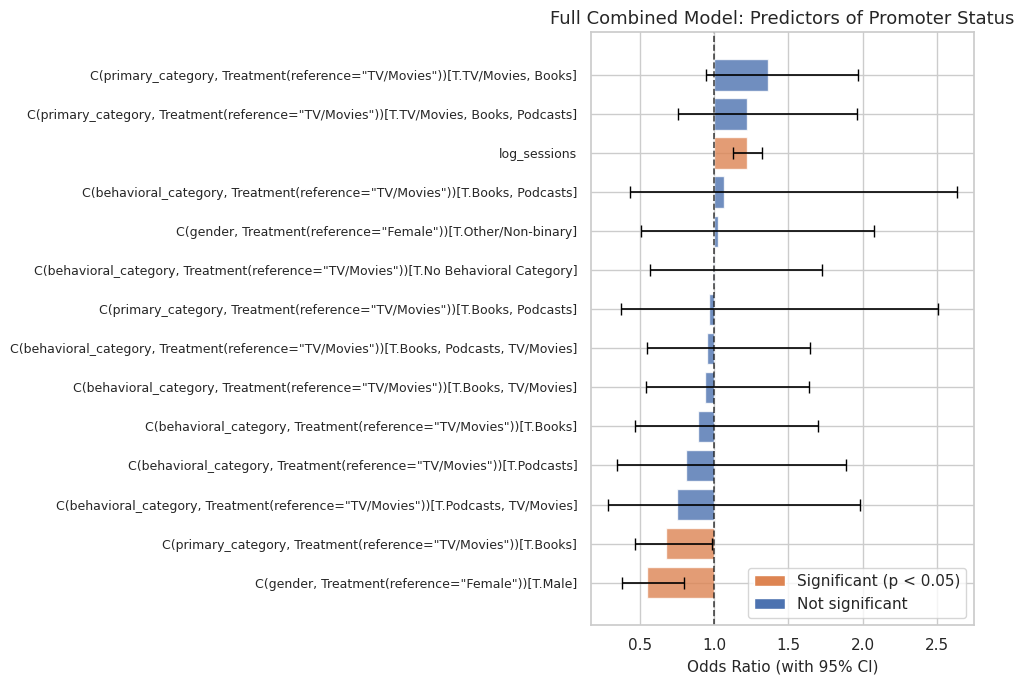

Saved: full_combined_regression_forest_plot.png


In [34]:
# Forest plot for the Full Combined Model
# This block will only execute if or_full was successfully created in the previous block.
if 'or_full' in locals():
    plot_df_full = or_full[or_full.index != 'Intercept'].copy().sort_values('Odds Ratio')
    colors_full  = ['#DD8452' if s else '#4C72B0' for s in plot_df_full['Significant']]

    fig_full, ax_full = plt.subplots(figsize=(10, max(6, len(plot_df_full) * 0.5)))
    ax_full.barh(range(len(plot_df_full)), plot_df_full['Odds Ratio'] - 1, left=1,
            color=colors_full, alpha=0.8, edgecolor='white')
    ax_full.errorbar(
        plot_df_full['Odds Ratio'], range(len(plot_df_full)),
        xerr=[plot_df_full['Odds Ratio'] - plot_df_full['95% CI Lower'],
              plot_df_full['95% CI Upper'] - plot_df_full['Odds Ratio']],
        fmt='none', color='black', capsize=4, linewidth=1.2
    )
    ax_full.axvline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax_full.set_yticks(range(len(plot_df_full)))
    ax_full.set_yticklabels(plot_df_full.index, fontsize=9)
    ax_full.set_xlabel('Odds Ratio (with 95% CI)', fontsize=11)
    ax_full.set_title('Full Combined Model: Predictors of Promoter Status', fontsize=13)
    ax_full.legend(handles=[
        Patch(facecolor='#DD8452', label='Significant (p < 0.05)'),
        Patch(facecolor='#4C72B0', label='Not significant')
    ], loc='lower right')

    plt.tight_layout()
    plt.savefig('full_combined_regression_forest_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: full_combined_regression_forest_plot.png')
else:
    print("Skipping forest plot: 'or_full' DataFrame not found. This indicates an issue in the preceding regression cell.")


In [35]:
print('=== FINDINGS SUMMARY ===')
print(f'Total respondents: {len(df)}')
print(f'App users: {len(df_app)} | Newsletter users: {len(df_news)}')
print(f'Overall Promoter rate: {df["is_promoter"].mean()*100:.1f}%')

print('\nPromoter rate by year:')
for yr in sorted(df['survey_year'].unique()):
    r = df[df['survey_year'] == yr]['is_promoter'].mean() * 100
    print(f'  {yr}: {r:.1f}%')

categories_to_drop = ['Podcasts', 'Books, Podcasts', 'TV/Movies, Podcasts']
filtered_df_summary = df[~df['primary_category'].isin(categories_to_drop)]
cat_rates = filtered_df_summary.groupby('primary_category')['is_promoter'].mean() * 100
print(f'\nHighest category Promoter rate (excluding low-count categories): {cat_rates.idxmax()} ({cat_rates.max():.1f}%)')
print(f'Lowest category Promoter rate (excluding low-count categories):  {cat_rates.idxmin()} ({cat_rates.min():.1f}%)')



=== FINDINGS SUMMARY ===
Total respondents: 1485
App users: 1360 | Newsletter users: 125
Overall Promoter rate: 32.9%

Promoter rate by year:
  21: 39.1%
  23: 37.5%
  24: 34.0%
  25: 26.1%

Highest category Promoter rate (excluding low-count categories): TV/Movies, Books (37.9%)
Lowest category Promoter rate (excluding low-count categories):  Books (26.9%)


---
## Export

In [36]:
df.to_csv('nps_analysis_clean.csv', index=False)
or_s6.to_csv('full_model_results.csv')
print('Saved: nps_analysis_clean.csv')
print('Saved: full_model_results.csv')

from google.colab import files
for fname in [
    'nps_analysis_clean.csv', 'full_model_results.csv',
    'p1_nps_trend.png', 'p2_category.png', 'p3_sessions.png', 'p4_user_type.png',
    's1_retention_sessions.png', 's2_retention_nps.png', 's3_genres.png',
    's4_demographics.png', 's5_followers.png', 's6_full_model.png'
]:
    try:
        files.download(fname)
    except Exception as e:
        print(f'Could not download {fname}: {e}')

Saved: nps_analysis_clean.csv
Saved: full_model_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>